In [2]:
import numpy as np
from datascience import *

In [3]:
tb_nba = Table.read_table('data/nba_salaries.csv')
tb_nba

rank,name,position,team,salary,season
1,Shaquille O'Neal,C,Los Angeles Lakers,17142000,2000
2,Kevin Garnett,PF,Minnesota Timberwolves,16806000,2000
3,Alonzo Mourning,C,Miami Heat,15004000,2000
4,Juwan Howard,PF,Washington Wizards,15000000,2000
5,Scottie Pippen,SF,Portland Trail Blazers,14795000,2000
6,Karl Malone,PF,Utah Jazz,14000000,2000
7,Larry Johnson,F,New York Knicks,11910000,2000
8,Gary Payton,PG,Seattle SuperSonics,11020000,2000
9,Rasheed Wallace,PF,Portland Trail Blazers,10800000,2000
10,Shawn Kemp,C,Cleveland Cavaliers,10780000,2000


In [4]:
tb_nba = tb_nba.where('season', 2020)

In [5]:
tb_nba.column('salary').mean()

7286796.9147727275

In [6]:
tb_warriors = tb_nba.where('team', 'Golden State Warriors')
tb_warriors

rank,name,position,team,salary,season
1,Stephen Curry,PG,Golden State Warriors,40231758,2020
13,Klay Thompson,SG,Golden State Warriors,32742000,2020
60,Draymond Green,PF,Golden State Warriors,18539130,2020
223,Kevon Looney,PF,Golden State Warriors,4464226,2020
316,Willie Cauley-Stein,C,Golden State Warriors,2177483,2020
332,Jordan Poole,SG,Golden State Warriors,1964760,2020
339,Omari Spellman,PF,Golden State Warriors,1897800,2020
496,Alen Smailagic,PF,Golden State Warriors,898310,2020
497,Eric Paschall,PF,Golden State Warriors,898310,2020
502,Damion Lee,SG,Golden State Warriors,842327,2020


In [7]:
tb_warriors.column('salary').mean()

8154688.538461538

In [8]:
team_means = tb_nba.group('team', collect=np.mean)
team_means.sort('salary mean', descending=True, distinct=False)

team,rank mean,name mean,position mean,salary mean,season mean
Denver Nuggets,232.308,,,9.75706e+06,2020
Minnesota Timberwolves,239.211,,,9.20566e+06,2020
Portland Trail Blazers,257.929,,,8.69554e+06,2020
Dallas Mavericks,205.125,,,8.42969e+06,2020
Orlando Magic,238.706,,,8.38645e+06,2020
LA Clippers,236.824,,,8.20037e+06,2020
Golden State Warriors,332.923,,,8.15469e+06,2020
Houston Rockets,291.235,,,8.05841e+06,2020
Oklahoma City Thunder,268,,,7.98599e+06,2020
Detroit Pistons,263.333,,,7.55149e+06,2020


In [9]:
tb_nba.where('team', 'Golden State Warriors').where('rank', are.below(15))

rank,name,position,team,salary,season
1,Stephen Curry,PG,Golden State Warriors,40231758,2020
13,Klay Thompson,SG,Golden State Warriors,32742000,2020


In [10]:
warriors = (
    tb_nba.where('team', 'Golden State Warriors')
    .drop('team')
    .relabeled('salary', '$')
)

In [11]:
warriors

rank,name,position,$,season
1,Stephen Curry,PG,40231758,2020
13,Klay Thompson,SG,32742000,2020
60,Draymond Green,PF,18539130,2020
223,Kevon Looney,PF,4464226,2020
316,Willie Cauley-Stein,C,2177483,2020
332,Jordan Poole,SG,1964760,2020
339,Omari Spellman,PF,1897800,2020
496,Alen Smailagic,PF,898310,2020
497,Eric Paschall,PF,898310,2020
502,Damion Lee,SG,842327,2020


In [79]:
salaries = warriors.select('$')

In [80]:
salaries

$
40231758
32742000
18539130
4464226
2177483
1964760
1897800
898310
898310
842327


In [81]:
type(salaries)

datascience.tables.Table

In [82]:
tb_nba.sort('salary',  descending=True)

rank,name,position,team,salary,season
1,Stephen Curry,PG,Golden State Warriors,40231758,2020
2,Chris Paul,PG,Oklahoma City Thunder,38506482,2020
3,Russell Westbrook,PG,Houston Rockets,38506482,2020
4,John Wall,PG,Washington Wizards,38199000,2020
5,Kevin Durant,SF,Brooklyn Nets,38199000,2020
6,James Harden,SG,Houston Rockets,38199000,2020
7,LeBron James,SF,Los Angeles Lakers,37436858,2020
8,Kyle Lowry,PG,Toronto Raptors,34996296,2020
9,Blake Griffin,PF,Detroit Pistons,34449964,2020
10,Tobias Harris,SF,Philadelphia 76ers,32742000,2020


In [83]:
np.max(warriors.column('$'))

40231758

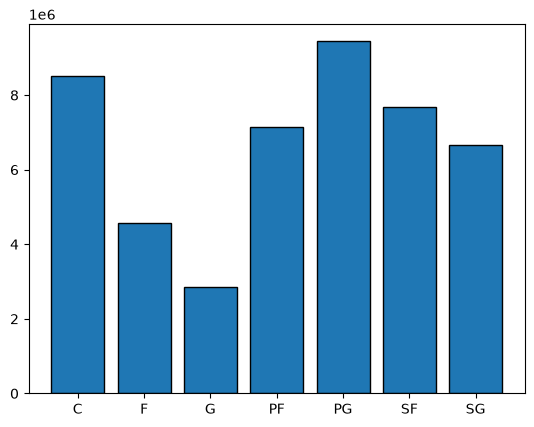

In [84]:
import matplotlib.pyplot as plt
%matplotlib inline

position_means = tb_nba.group('position', collect=np.mean)
position_means

plt.bar(position_means.column('position'), position_means.column("salary mean"))
plt.show()

In [85]:
warriors.show(warriors.num_rows)

rank,name,position,$,season
1,Stephen Curry,PG,40231758,2020
13,Klay Thompson,SG,32742000,2020
60,Draymond Green,PF,18539130,2020
223,Kevon Looney,PF,4464226,2020
316,Willie Cauley-Stein,C,2177483,2020
332,Jordan Poole,SG,1964760,2020
339,Omari Spellman,PF,1897800,2020
496,Alen Smailagic,PF,898310,2020
497,Eric Paschall,PF,898310,2020
502,Damion Lee,SG,842327,2020


In [86]:
salary = np.mean(tb_nba.column('salary'))
salary

7286796.9147727275

In [87]:
np.max(tb_nba.column('season'))

2020

In [88]:
np.arange(5, 11)

array([ 5,  6,  7,  8,  9, 10])

In [89]:
np.sum((warriors.take(np.arange(5))).column('$'))

98154597

In [90]:
warriors.select("rank", "name")

rank,name
1,Stephen Curry
13,Klay Thompson
60,Draymond Green
223,Kevon Looney
316,Willie Cauley-Stein
332,Jordan Poole
339,Omari Spellman
496,Alen Smailagic
497,Eric Paschall
502,Damion Lee


In [91]:
# warriors.select(np.arange(0, 2))

#### Ways to create a table

In [92]:
streets = make_array('Harmony', 'Horsetooth', 'Drake', 'Prospect')
streets

array(['Harmony', 'Horsetooth', 'Drake', 'Prospect'],
      dtype='<U10')

In [93]:
south = Table().with_columns("Street", streets)
south

Street
Harmony
Horsetooth
Drake
Prospect


In [101]:
south = south.with_column("blocks", np.arange(0,4))


In [102]:
south

Street,blocks
Harmony,0
Horsetooth,1
Drake,2
Prospect,3


In [103]:
south.select('blocks')

blocks
0
1
2
3


### Accessing a cell in a table

In [104]:
south.column_index('blocks')

1

In [105]:
south.row(3).item('blocks')

3

In [99]:
south.where('Street', 'Drake').take(0)['blocks'].item(0)

2

In [106]:
column_blocks = south.pop(1)

In [110]:
column_blocks[3] = 8
south = south.with_column('Blocks', column_blocks)

In [111]:
south

Street,Blocks
Harmony,0
Horsetooth,1
Drake,2
Prospect,8
